In [117]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [118]:
plasma = pd.read_csv('20p0mTorr_0.49kV_60A_spectrum_data.csv')
background = pd.read_csv('Testing/back7.csv')


FileNotFoundError: [Errno 2] No such file or directory: '20p0mTorr_0.49kV_60A_spectrum_data.csv'

In [36]:
plasma.head()

,Wavelength_nm,Intensity
0,317.779,0.232260
1,318.882,0.202812
2,319.985,0.225759
3,321.088,0.200531
4,322.191,0.224219


In [37]:
background.head()

,Wavelength_nm,Intensity
0,317.779,0.000319
1,318.882,0.000409
2,319.985,0.000672
3,321.088,0.001171
4,322.191,0.001056


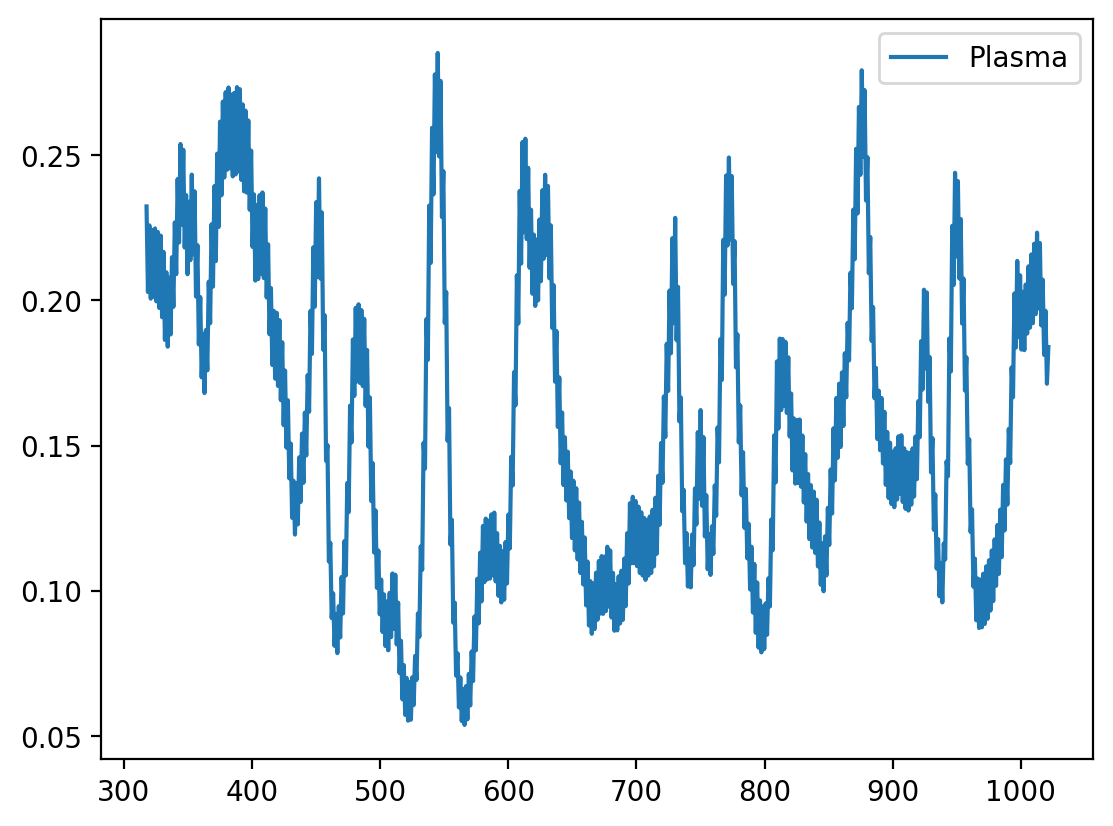

In [ ]:
plt.figure(dpi=200)
plt.plot(plasma['Wavelength_nm'], plasma['Intensity'], label='Plasma')
#plt.plot(background['Wavelength_nm'], background['Intensity'], label='background')
plt.legend()

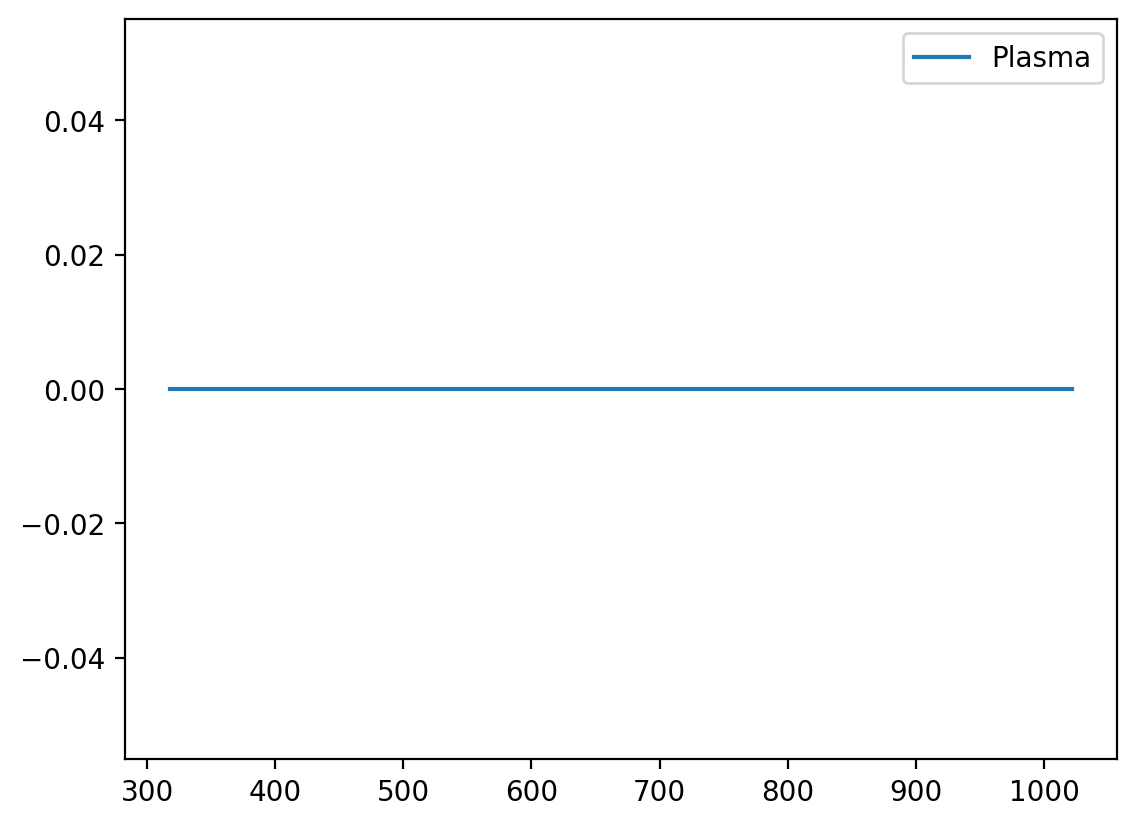

In [119]:
plt.figure(dpi=200)
plt.plot(plasma['Wavelength_nm'], (plasma['Intensity']-background['Intensity']).clip(lower=0), label='Plasma')
plt.legend()

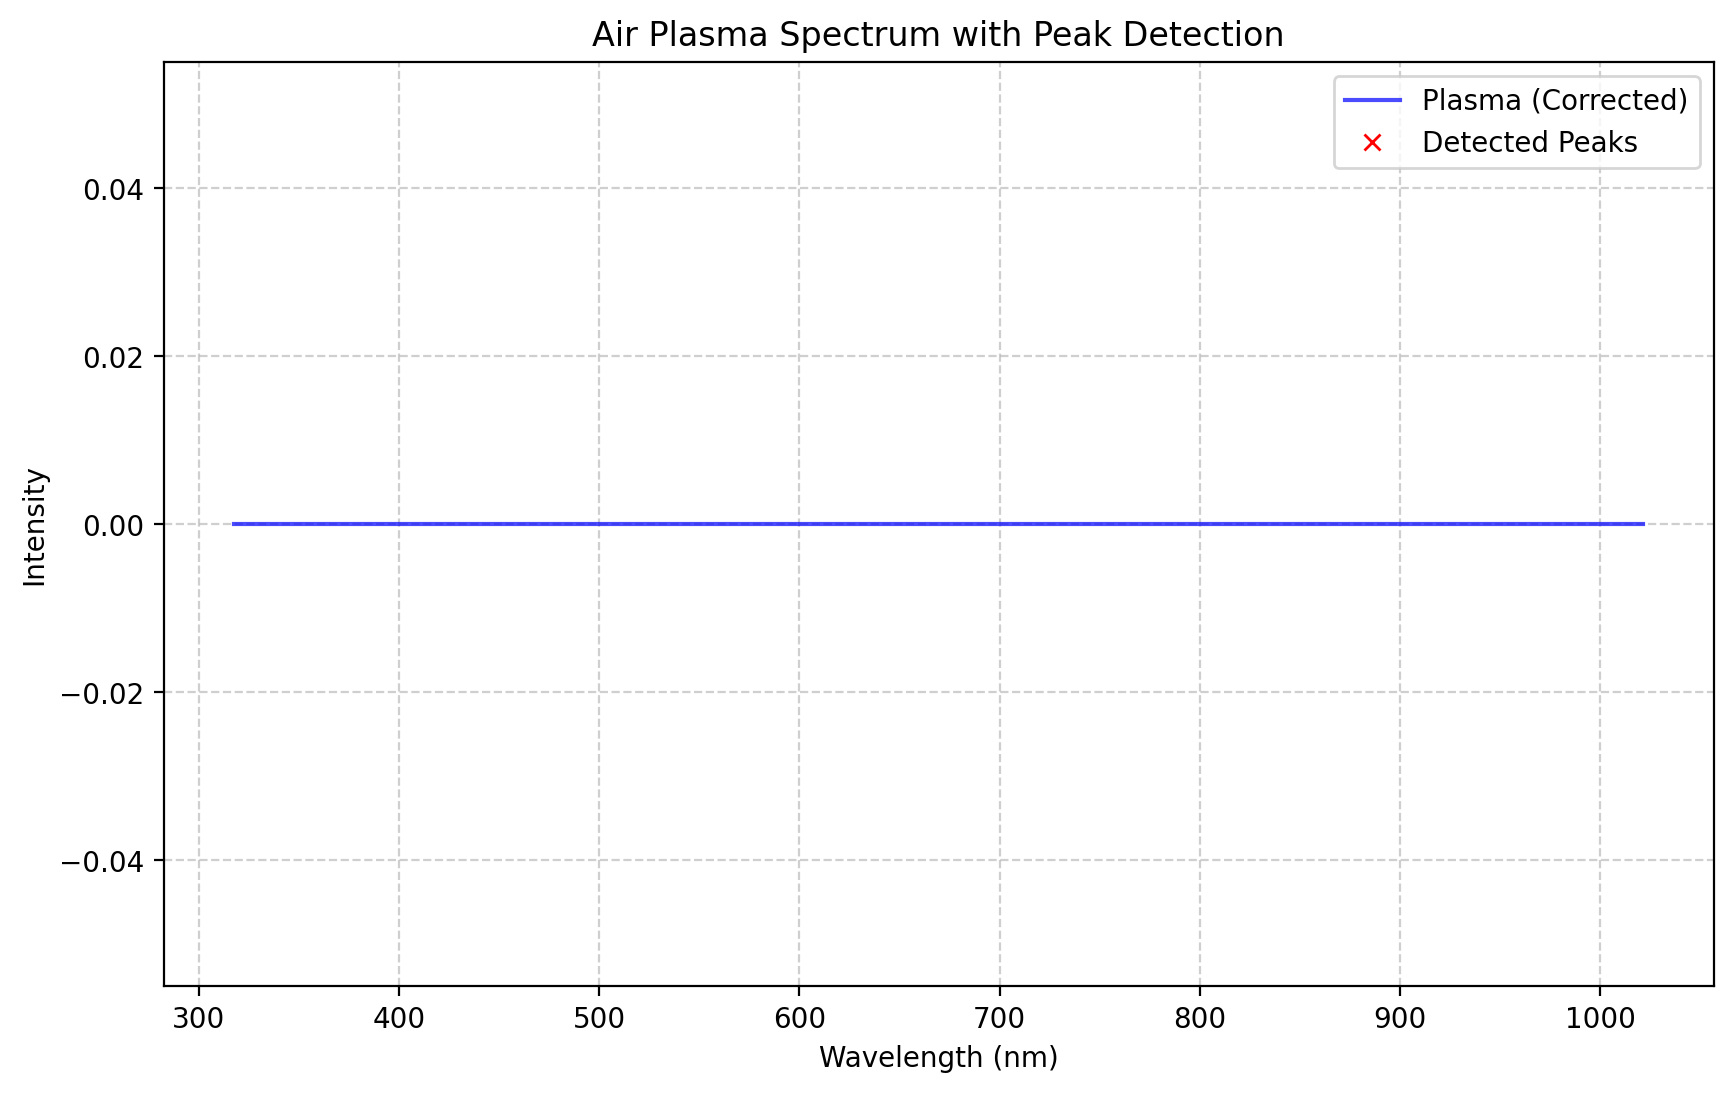

   Target_nm  Actual_nm    Height   FWHM_nm
0        380    379.547  0.000376  3.808797
1        481     479.92  0.000105  5.325914
2        630  Not Found  0.000000  0.000000
3        725    721.477  0.000157  4.313956
4        770  Not Found  0.000000  0.000000
5        880    880.309  0.000052  9.651250
6        950    947.592  0.000038  3.309000
{'r1': nan, 'r2': np.float64(0.5), 'r3': np.float64(0.27848103007157754), 'r4': nan, 'r5': nan, 'r6': nan}


In [125]:
from scipy.signal import find_peaks,peak_widths

# 1. Calculate the corrected intensity
# We clip at 0 because negative intensity values (noise) don't represent a signal
corrected_intensity = (plasma['Intensity'] - background['Intensity']).clip(lower=0)
wavelengths = plasma['Wavelength_nm']

# 2. Find the peaks
# 'prominence' is key: it ignores small ripples/noise. 
# Adjust 'prominence' based on your signal-to-noise ratio.
peaks, properties = find_peaks(corrected_intensity, prominence = 0.003)

# 3. Plotting
plt.figure(figsize=(10, 6), dpi=200)
plt.plot(wavelengths, corrected_intensity, label='Plasma (Corrected)', color='blue', alpha=0.7)

# Plot the identified peaks
plt.plot(wavelengths.iloc[peaks], corrected_intensity.iloc[peaks], "x", color='red', label='Detected Peaks')

# Optional: Annotate the peaks with their wavelength
for i in peaks:
    plt.annotate(f"{wavelengths.iloc[i]:.1f}nm", 
                 (wavelengths.iloc[i], corrected_intensity.iloc[i]),
                 textcoords="offset points", xytext=(0,10), ha='center', fontsize=8)

plt.xlabel('Wavelength (nm)')
plt.ylabel('Intensity')
plt.title('Air Plasma Spectrum with Peak Detection')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()



def analyze_specific_peaks(df, targets, window=15):
    """
    Finds specific peaks, returns heights and FWHM in nm.
    """
    wavelengths = df['Wavelength_nm'].values
    intensity = (df['Intensity'])# - background['Intensity']).clip(lower=0).values
    prominence = max(intensity)*0.1
    
    nm_per_pixel = np.mean(np.diff(wavelengths))

    peaks, props = find_peaks(intensity, prominence=prominence)

    widths_indices = peak_widths(intensity, peaks, rel_height=0.5)[0]

    results = []

    for target in targets:
        diffs = np.abs(wavelengths[peaks] - target)
        closest_idx = np.argmin(diffs)
        
        if diffs[closest_idx] <= window:
            p_idx = peaks[closest_idx]
            actual_wl = wavelengths[p_idx]
            height = intensity[p_idx]
            
            fwhm_nm = widths_indices[closest_idx] * nm_per_pixel


            results.append({
                "Target_nm": target,
                "Actual_nm": actual_wl,
                "Height": height,
                "FWHM_nm": fwhm_nm
            })
        else:
            results.append({
                "Target_nm": target,
                "Actual_nm": "Not Found",
                "Height": 0,
                "FWHM_nm": 0
            })

    return pd.DataFrame(results)

target_list = [380,481,630,725,770, 880, 950]
peak_data = analyze_specific_peaks(plasma, target_list)

print(peak_data)

def peak_ratios(peak_data):
    pk1 = peak_data.loc[peak_data['Target_nm'] == 380, 'Height'].values[0]
    pk2 = peak_data.loc[peak_data['Target_nm'] == 481, 'Height'].values[0]
    pk3 = peak_data.loc[peak_data['Target_nm'] == 630, 'Height'].values[0]
    pk4 = peak_data.loc[peak_data['Target_nm'] == 725, 'Height'].values[0]
    pk5 = peak_data.loc[peak_data['Target_nm'] == 770, 'Height'].values[0]
    pk6 = peak_data.loc[peak_data['Target_nm'] == 880, 'Height'].values[0]
    pk7 = peak_data.loc[peak_data['Target_nm'] == 950, 'Height'].values[0]
    ratio1 = pk5 / pk1 if (pk1 and pk5)  != 0 else np.nan
    ratio2 = pk6/pk2 if (pk2 and pk6) != 0 else np.nan
    ratio3 = pk2/pk1 if (pk1 and pk2) != 0 else np.nan
    ratio4 = pk5/pk4 if (pk4 and pk5) != 0 else np.nan
    ratio5= pk7/pk3 if (pk3 and pk7) != 0 else np.nan
    return {
        "r1": ratio1,
        "r2": ratio2,
        "r3": ratio3,
        "r4": ratio4,
        "r5": ratio5,
        "r6": np.nan
    }



# def peak_ratios(peak_data):
#     pk1 = peak_data.loc[peak_data['Target_nm'] == 380, 'Height'].values[0]
#     pk2 = peak_data.loc[peak_data['Target_nm'] == 481, 'Height'].values[0]
#     pk3 = peak_data.loc[peak_data['Target_nm'] == 630, 'Height'].values[0]
#     pk4 = peak_data.loc[peak_data['Target_nm'] == 725, 'Height'].values[0]
#     pk5 = peak_data.loc[peak_data['Target_nm'] == 770, 'Height'].values[0]
#     pk6 = peak_data.loc[peak_data['Target_nm'] == 880, 'Height'].values[0]
#     pk7 = peak_data.loc[peak_data['Target_nm'] == 950, 'Height'].values[0]
#     ratio1 = pk1 / pk6 if pk6 != 0 else np.nan
#     ratio2 = pk2/pk6 if pk6 != 0 else np.nan
#     ratio3 = pk3/pk6 if pk6 != 0 else np.nan
#     ratio4 = pk4/pk6 if pk6 != 0 else np.nan
#     ratio5= pk5/pk6 if pk6 != 0 else np.nan
#     ratio6 = pk7/pk6 if pk6 != 0 else np.nan

    
#     return {
#         "r1": ratio1,
#         "r2": ratio2,
#         "r3": ratio3,
#         "r4": ratio4,
#         "r5": ratio5,
#         'r6':ratio6

#     }

ratios = peak_ratios(peak_data)
print(ratios)

In [131]:
import os
import re

folder_path = './Data/'  # Change this to the path where your CSVs are stored

all_results = []

print(f"{'File':<40} | {'Press':<8} | {'kV':<6} | {'Amps':<5}")
print("-" * 75)

for filename in os.listdir(folder_path):
    if filename.endswith(".csv") and "_spectrum_data" in filename:
        # 1. Parse Filename (Extract 15.7, 0.48, 60)
        # Pattern looks for numbers followed by units
        try:
            pressure = re.search(r'([\dpt]+)mTorr', filename).group(1).replace('p', '.')
            voltage = re.search(r'([\dpt]+)kV', filename).group(1).replace('p', '.')
            current = re.search(r'([\dpt]+)A', filename).group(1).replace('p', '.')
        except AttributeError:
            continue # Skip files that don't match the naming convention

        # 2. Load File
        file_path = os.path.join(folder_path, filename)
        print(file_path)
        plasma = pd.read_csv(file_path)

        # 3. Analyze
        peak_results = analyze_specific_peaks(plasma, target_list, window=15)
        rat_results = peak_ratios(peak_results)

        # 4. Store Data
        row = {
            'File': filename,
            'Pressure_mTorr': float(pressure),
            'Voltage_kV': float(voltage),
            'Current_A': float(current),
            'rat1': rat_results['r1'],
            'rat2': rat_results['r2'],
            'rat3': rat_results['r3'],
            'rat4': rat_results['r4'],
            'rat5': rat_results['r5'],
            'rat6': rat_results['r6']
        }
        
            
        all_results.append(row)
        print(f"{filename[:38]:<40} | {pressure:<8} | {voltage:<6} | {current:<5}")

# 5. Create Master Summary DataFrame
summary_df = pd.DataFrame(all_results)
summary_df.to_csv("experiment_summary_norm.csv", index=False)
print("\nBatch processing complete. Summary saved to 'experiment_summary_norm.csv'.")

File                                     | Press    | kV     | Amps 
---------------------------------------------------------------------------
./Data/51p5mTorr_0.38kV_60A_spectrum_data.csv
51p5mTorr_0.38kV_60A_spectrum_data.csv   | 51.5     | 38     | 60   
./Data/20p0mTorr_0.49kV_60A_spectrum_data.csv
20p0mTorr_0.49kV_60A_spectrum_data.csv   | 20.0     | 49     | 60   
./Data/24p6mTorr_0.46kV_40A_spectrum_data.csv
24p6mTorr_0.46kV_40A_spectrum_data.csv   | 24.6     | 46     | 40   
./Data/17p3mTorr_0.41kV_20A_spectrum_data.csv
17p3mTorr_0.41kV_20A_spectrum_data.csv   | 17.3     | 41     | 20   
./Data/35p6mTorr_0.48kV_70A_spectrum_data.csv
35p6mTorr_0.48kV_70A_spectrum_data.csv   | 35.6     | 48     | 70   
./Data/17p3mTorr_0.41kV_30A_spectrum_data.csv
17p3mTorr_0.41kV_30A_spectrum_data.csv   | 17.3     | 41     | 30   
./Data/64p6mTorr_0.39kV_80A_spectrum_data.csv
64p6mTorr_0.39kV_80A_spectrum_data.csv   | 64.6     | 39     | 80   
./Data/93p3mTorr_0.38kV_70A_spectrum_data.csv
93p3

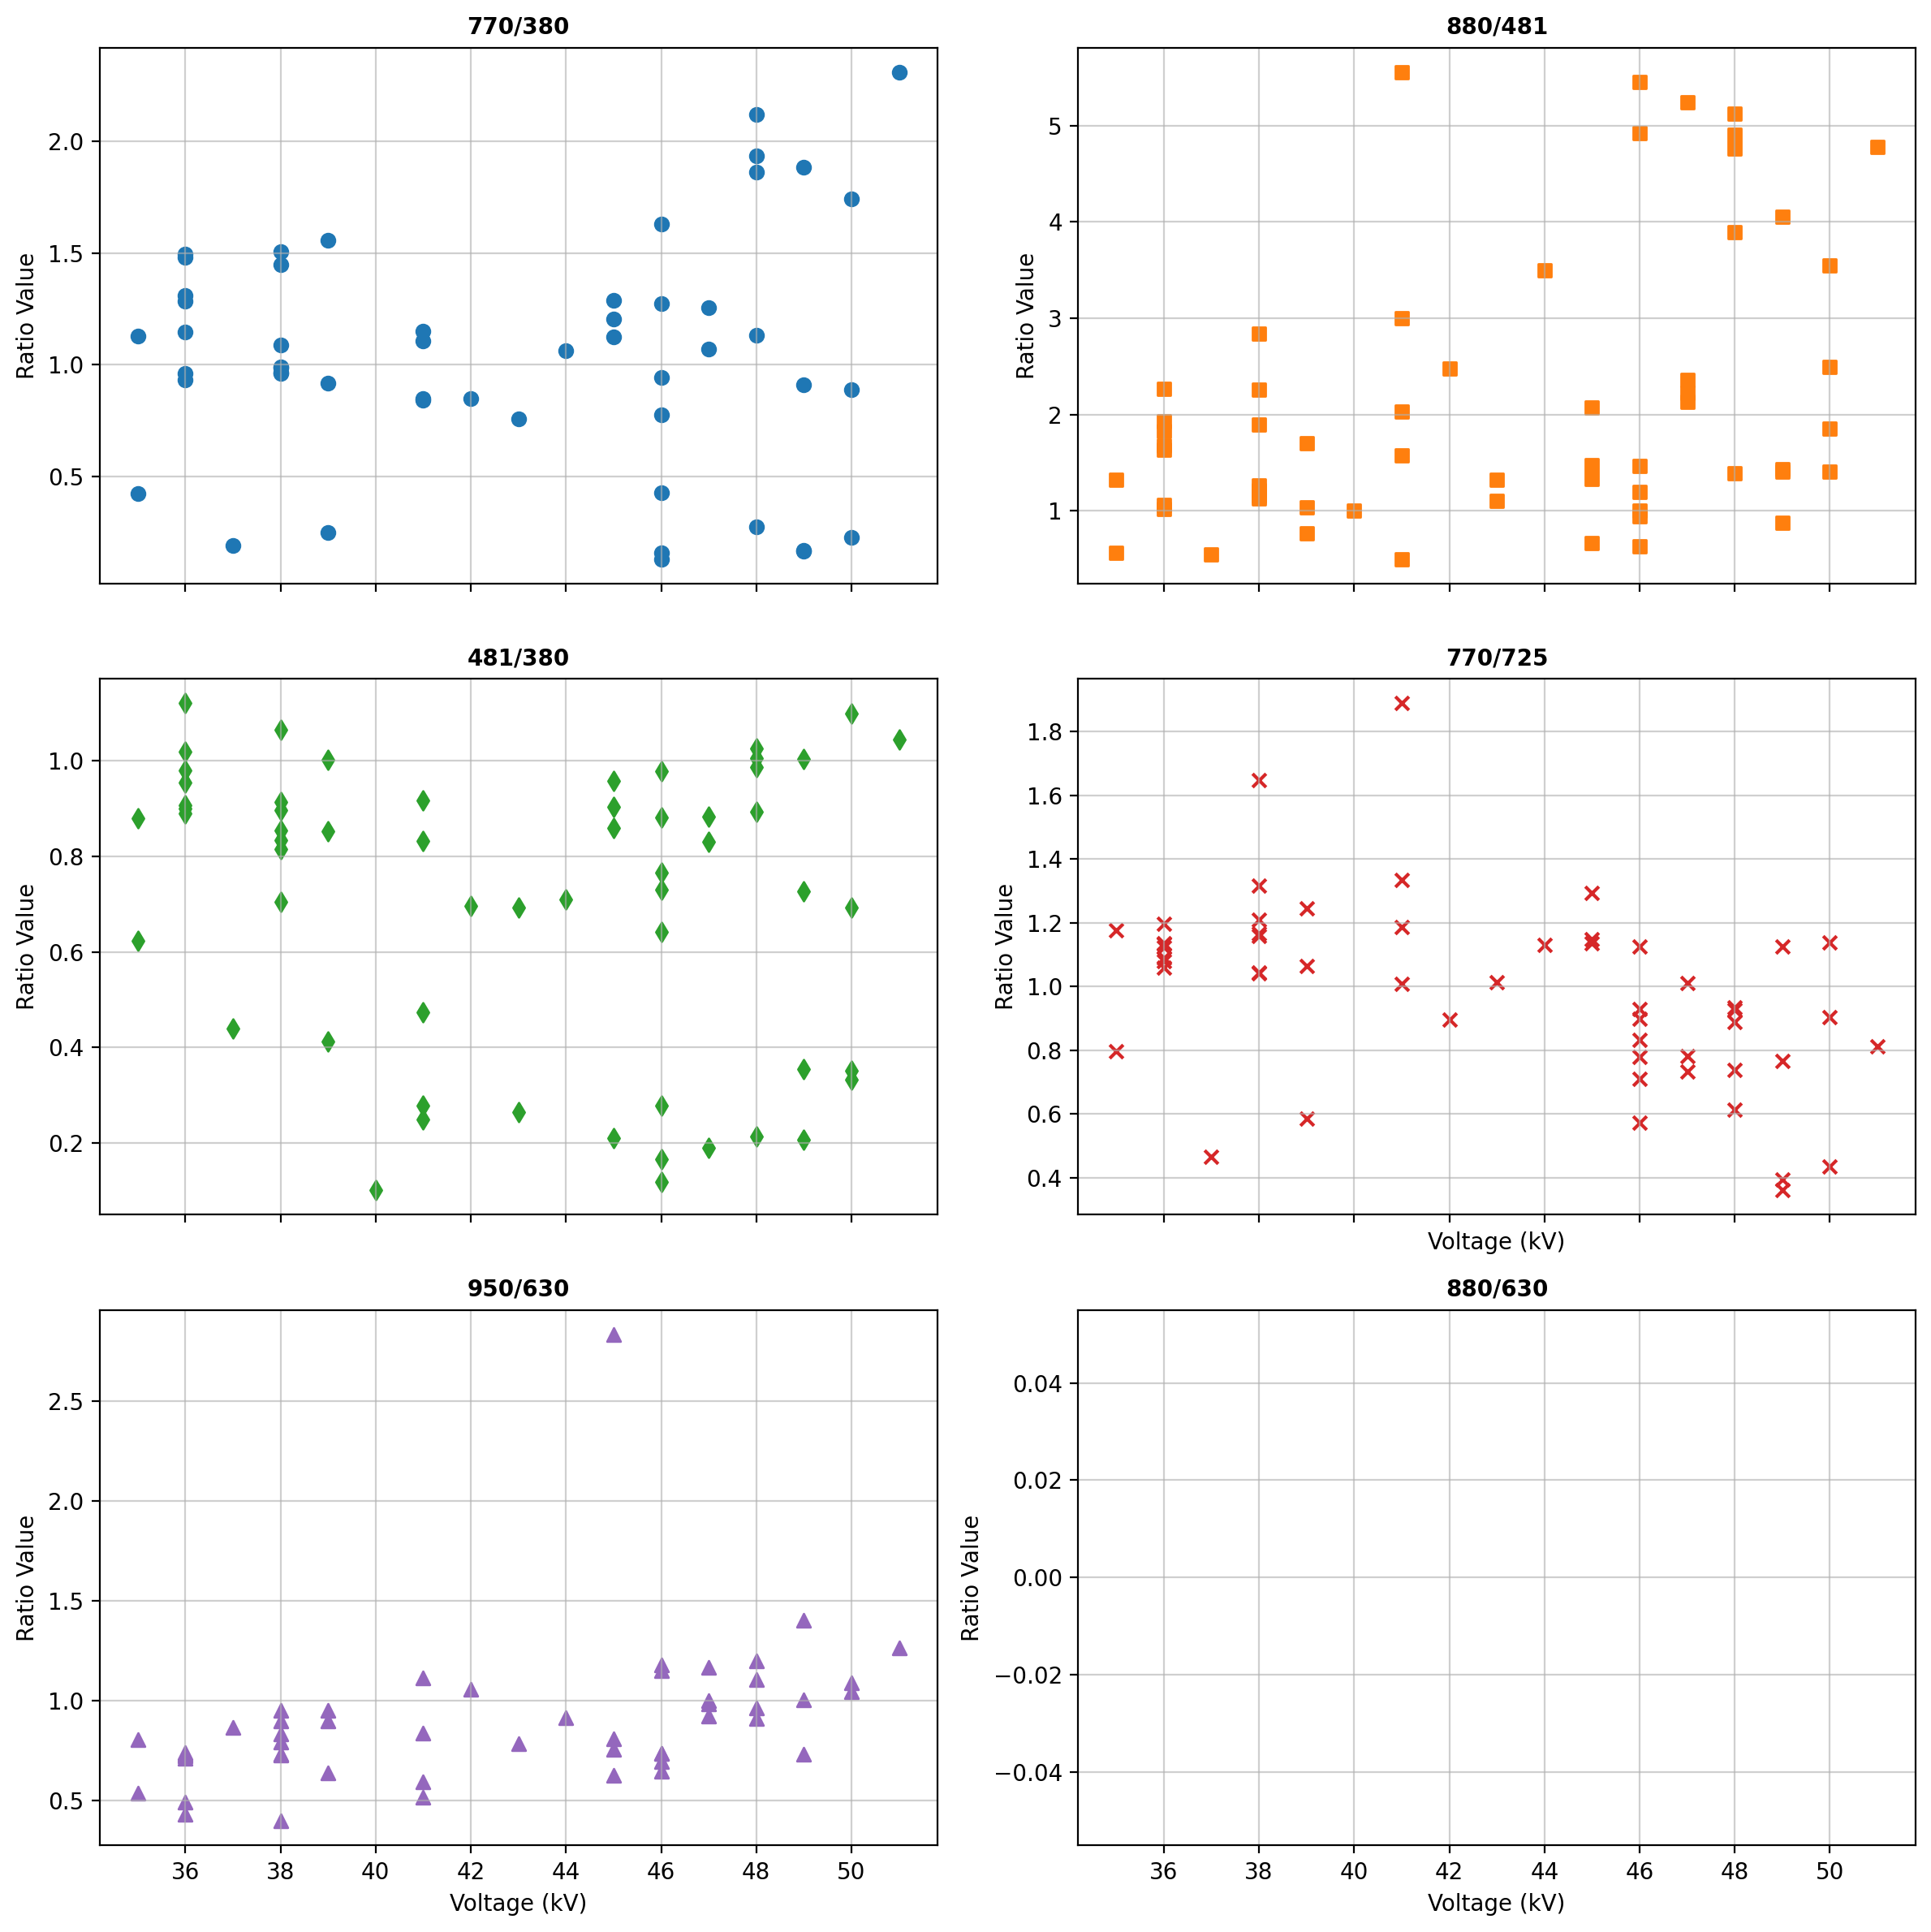

In [137]:

# 1. Sort the data first to ensure lines connect correctly
summary_df = summary_df.sort_values(by='Voltage_kV')

# 2. Define the ratios, markers, and labels for the loop
ratios = ['rat1', 'rat2', 'rat3', 'rat4', 'rat5', 'rat6']
labels = ['770/380', '880/481', '481/380', '770/725', '950/630', '880/630']
markers = ['o', 's', 'd', 'x', '^', 'v']
colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd', '#8c564b']

# 3. Create the subplot array (3 rows, 2 columns)
fig, axes = plt.subplots(3, 2, figsize=(12, 12), dpi=200, sharex=True)
axes = axes.flatten()  # Flatten to 1D array for easy iteration

for i in range(len(ratios)):
    ax = axes[i]
    ratio_col = ratios[i]
    
    # Plot the data
    ax.scatter(summary_df['Voltage_kV'], summary_df[ratio_col], 
            marker=markers[i], color=colors[i], label=labels[i])
    
    # Formatting each subplot
    ax.set_title(labels[i], fontsize=10, fontweight='bold')
    ax.set_ylabel('Ratio Value')
    ax.grid(True, alpha=0.6)
    
    # Only add X-label to the bottom-most plots
    if i >= 3:
        ax.set_xlabel('Voltage (kV)')


plt.tight_layout()
plt.show()

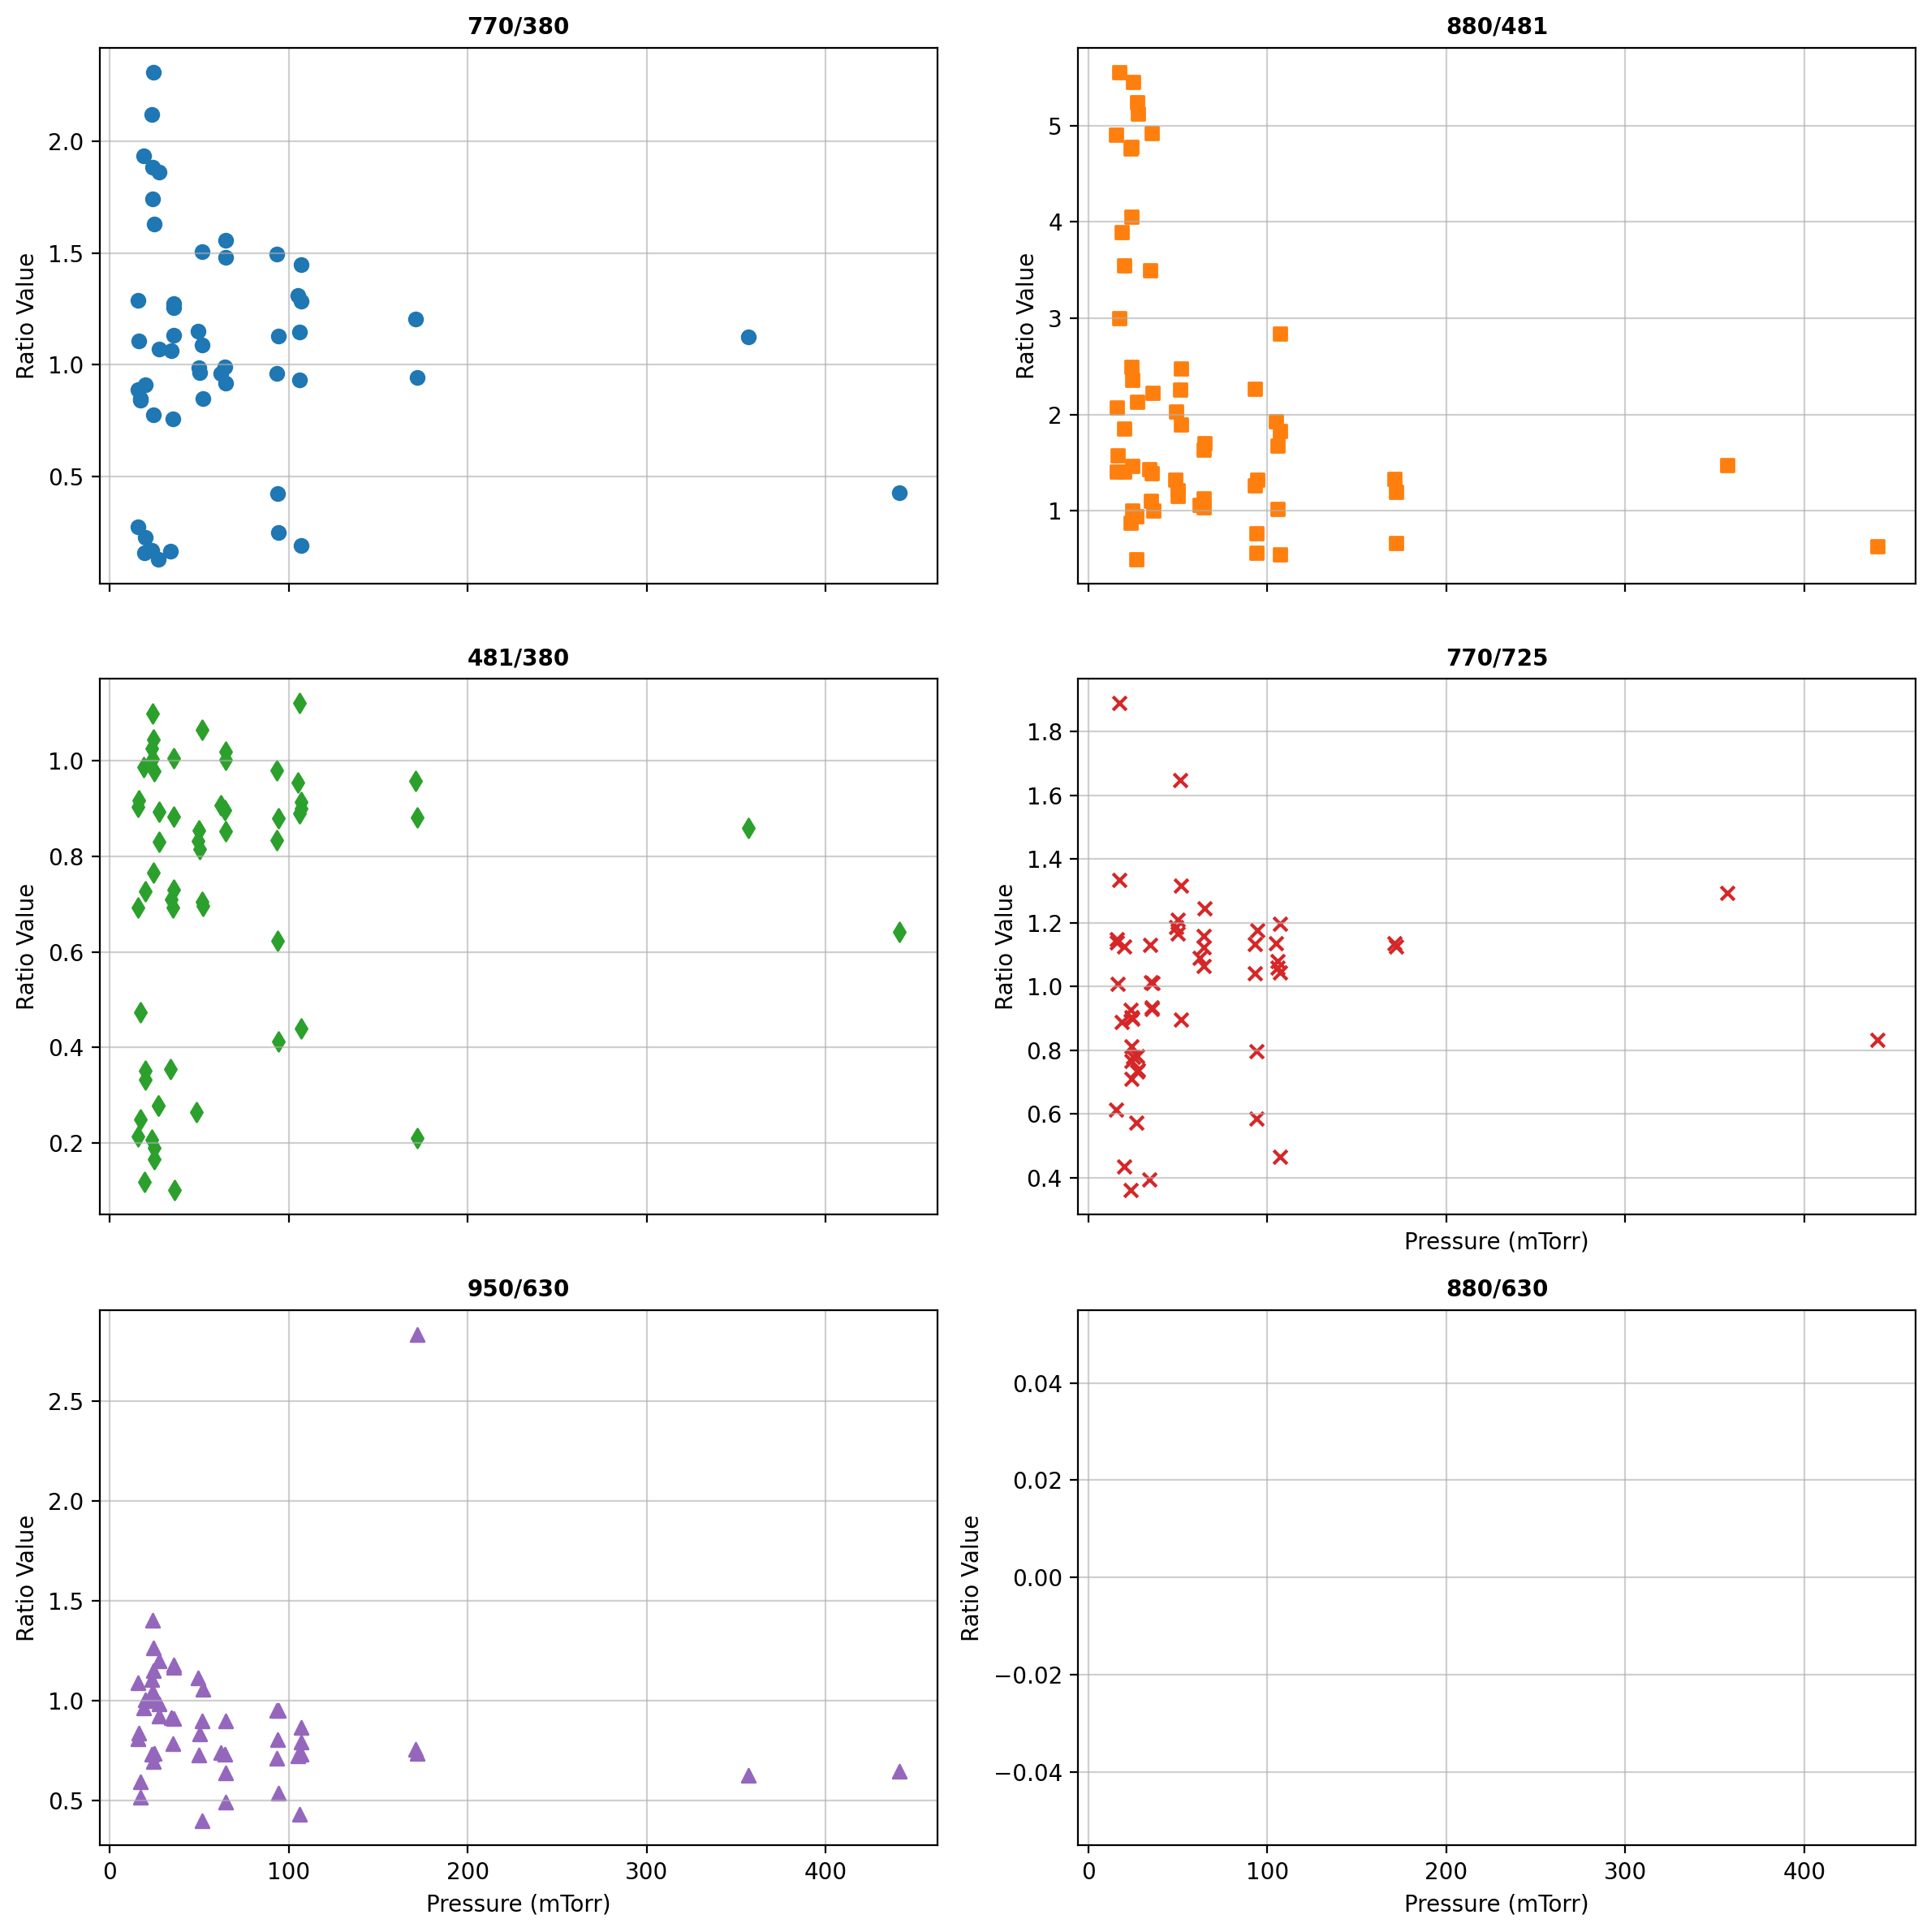

In [133]:

# 1. Sort the data first to ensure lines connect correctly
summary_df = summary_df.sort_values(by='Pressure_mTorr')

# 2. Define the ratios, markers, and labels for the loop
ratios = ['rat1', 'rat2', 'rat3', 'rat4', 'rat5', 'rat6']
labels = ['770/380', '880/481', '481/380', '770/725', '950/630', '880/630']
markers = ['o', 's', 'd', 'x', '^', 'v']
colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd', '#8c564b']

# 3. Create the subplot array (3 rows, 2 columns)
fig, axes = plt.subplots(3, 2, figsize=(12, 12), dpi=200, sharex=True)
axes = axes.flatten()  # Flatten to 1D array for easy iteration

for i in range(len(ratios)):
    ax = axes[i]
    ratio_col = ratios[i]
    
    # Plot the data
    ax.scatter(summary_df['Pressure_mTorr'], summary_df[ratio_col], 
            marker=markers[i], color=colors[i], label=labels[i])
    
    # Formatting each subplot
    ax.set_title(labels[i], fontsize=10, fontweight='bold')
    ax.set_ylabel('Ratio Value')
    ax.grid(True, alpha=0.6)
    
    # Only add X-label to the bottom-most plots
    if i >= 3:
        ax.set_xlabel('Pressure (mTorr)')


plt.tight_layout()
plt.show()

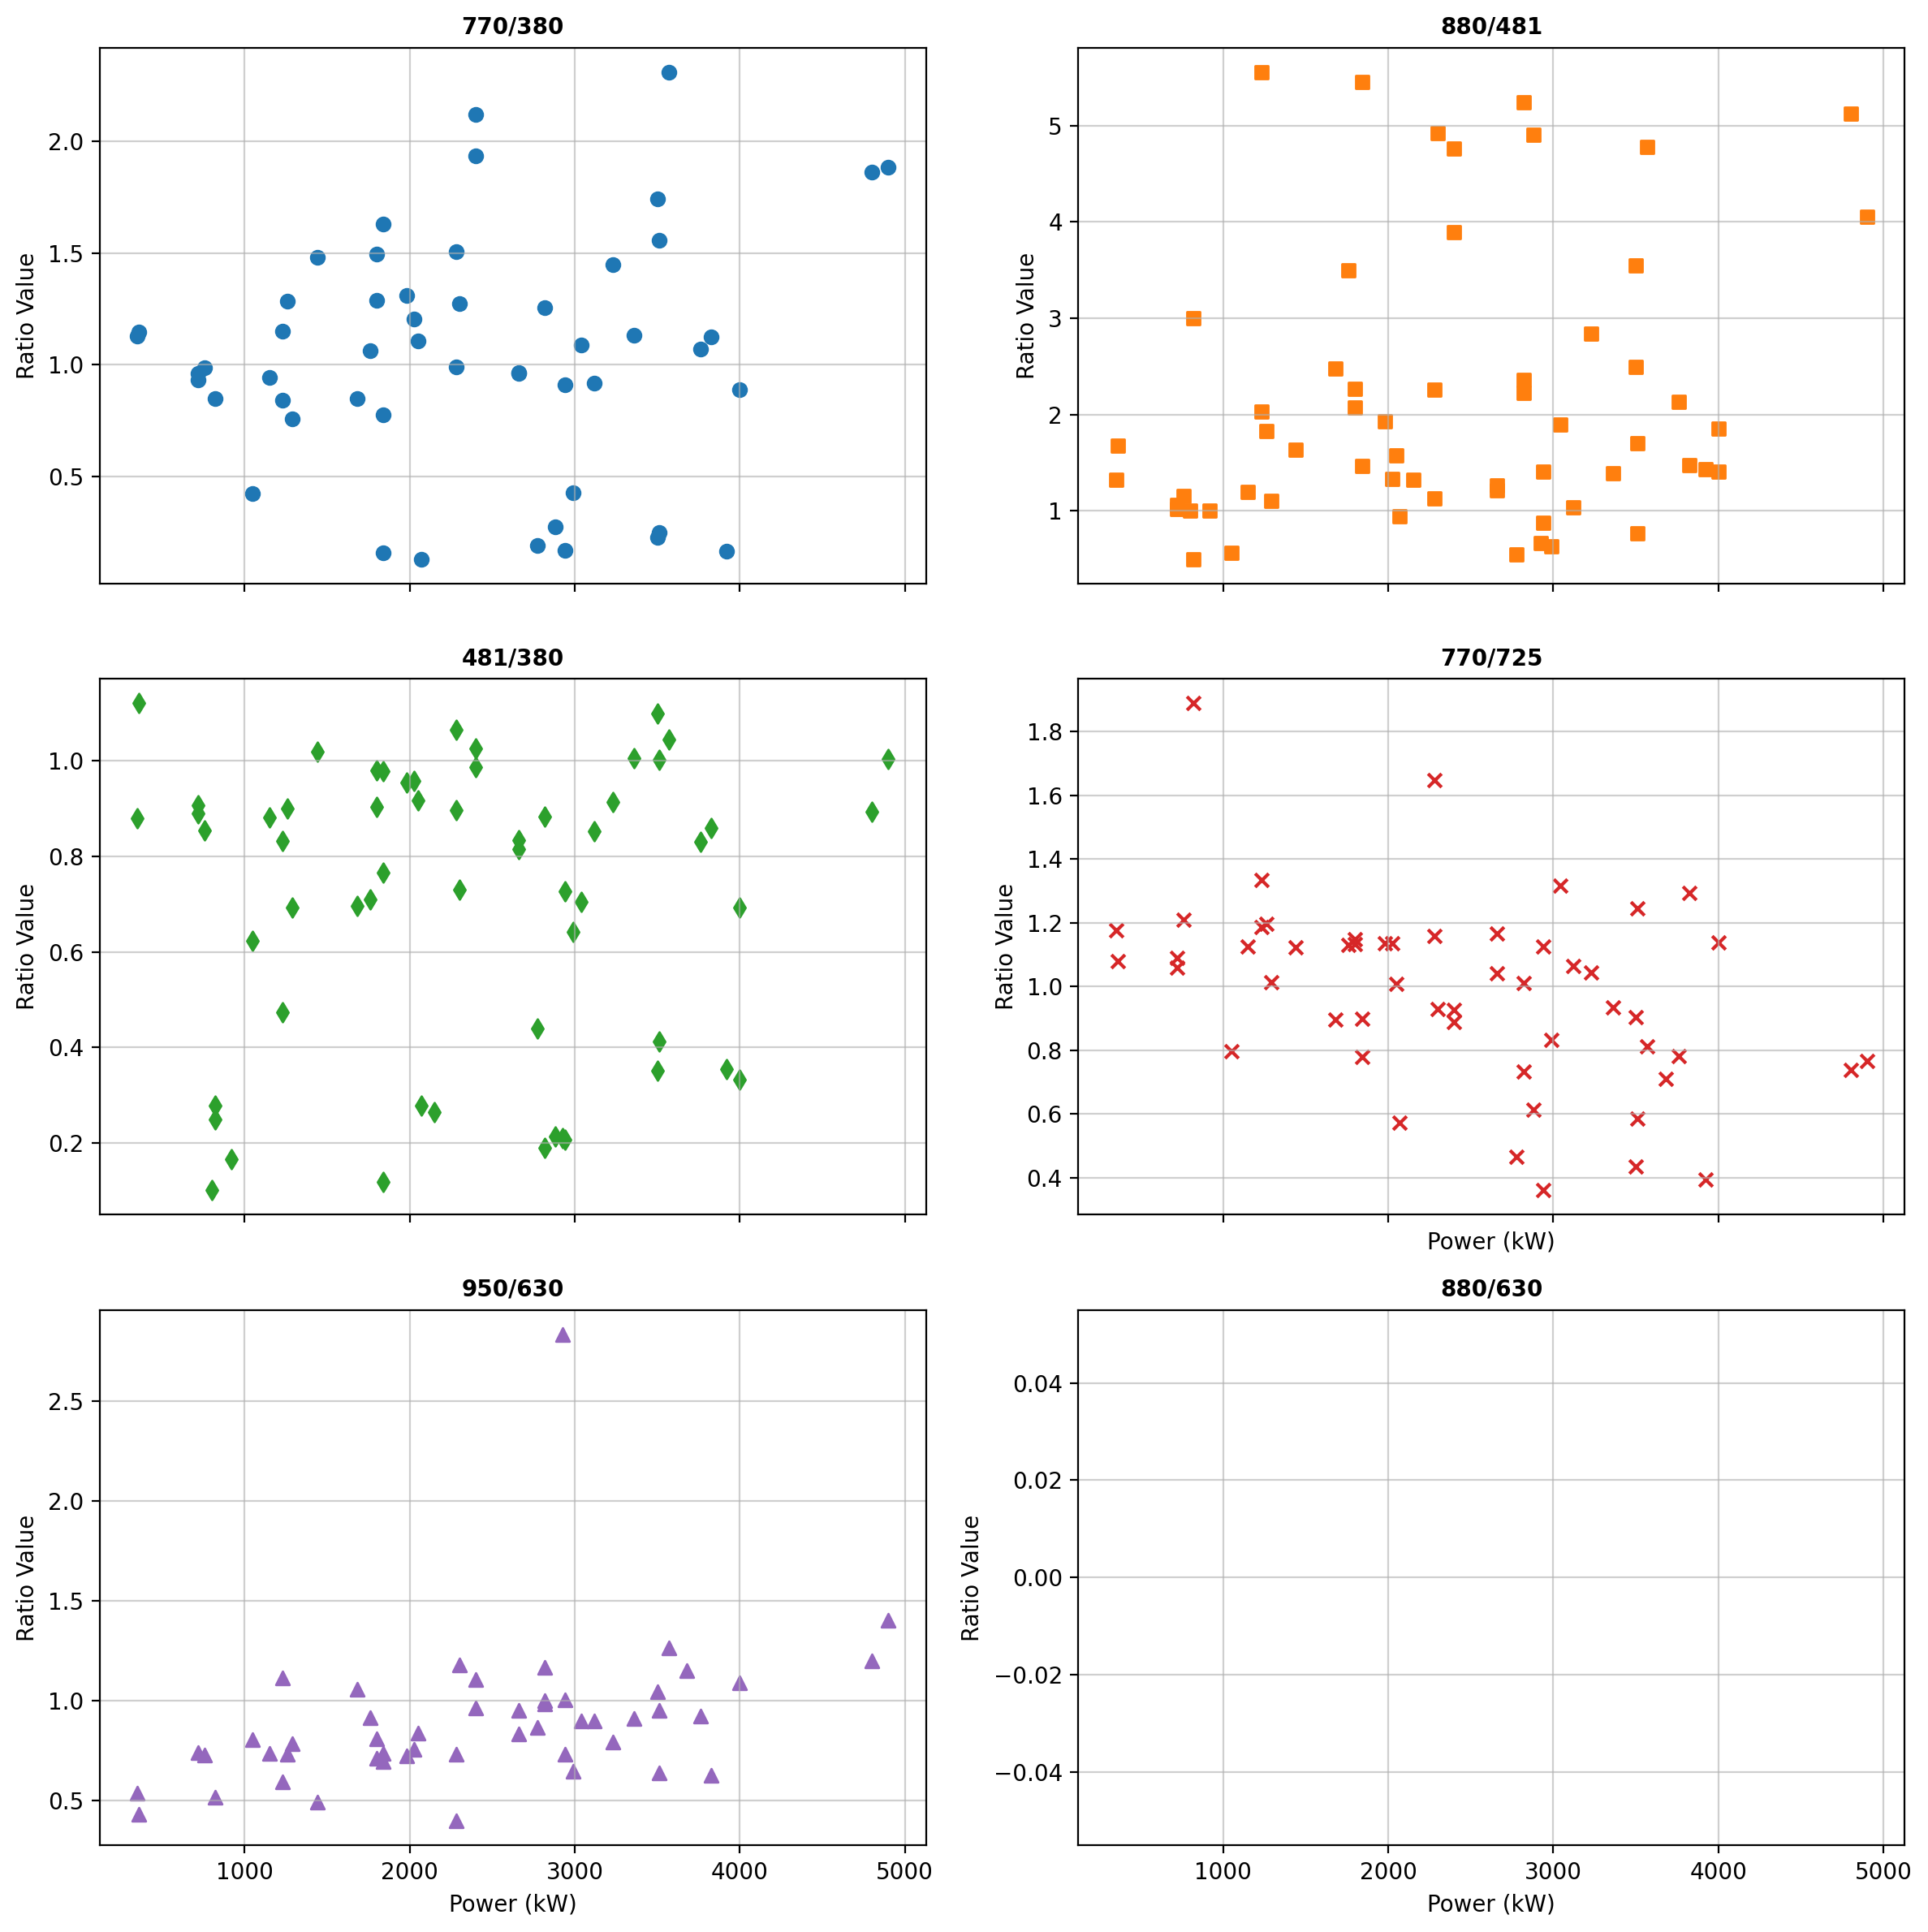

In [134]:


# 2. Define the ratios, markers, and labels for the loop
ratios = ['rat1', 'rat2', 'rat3', 'rat4', 'rat5', 'rat6']
labels = ['770/380', '880/481', '481/380', '770/725', '950/630', '880/630']
markers = ['o', 's', 'd', 'x', '^', 'v']
colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd', '#8c564b']

# 3. Create the subplot array (3 rows, 2 columns)
fig, axes = plt.subplots(3, 2, figsize=(12, 12), dpi=200, sharex=True)
axes = axes.flatten()  # Flatten to 1D array for easy iteration

for i in range(len(ratios)):
    ax = axes[i]
    ratio_col = ratios[i]
    
    # Plot the data
    ax.scatter(summary_df['Voltage_kV']*summary_df['Current_A'], summary_df[ratio_col], 
            marker=markers[i], color=colors[i], label=labels[i])
    
    # Formatting each subplot
    ax.set_title(labels[i], fontsize=10, fontweight='bold')
    ax.set_ylabel('Ratio Value')
    ax.grid(True, alpha=0.6)
    
    # Only add X-label to the bottom-most plots
    if i >= 3:
        ax.set_xlabel('Power (kW)')


plt.tight_layout()
plt.show()

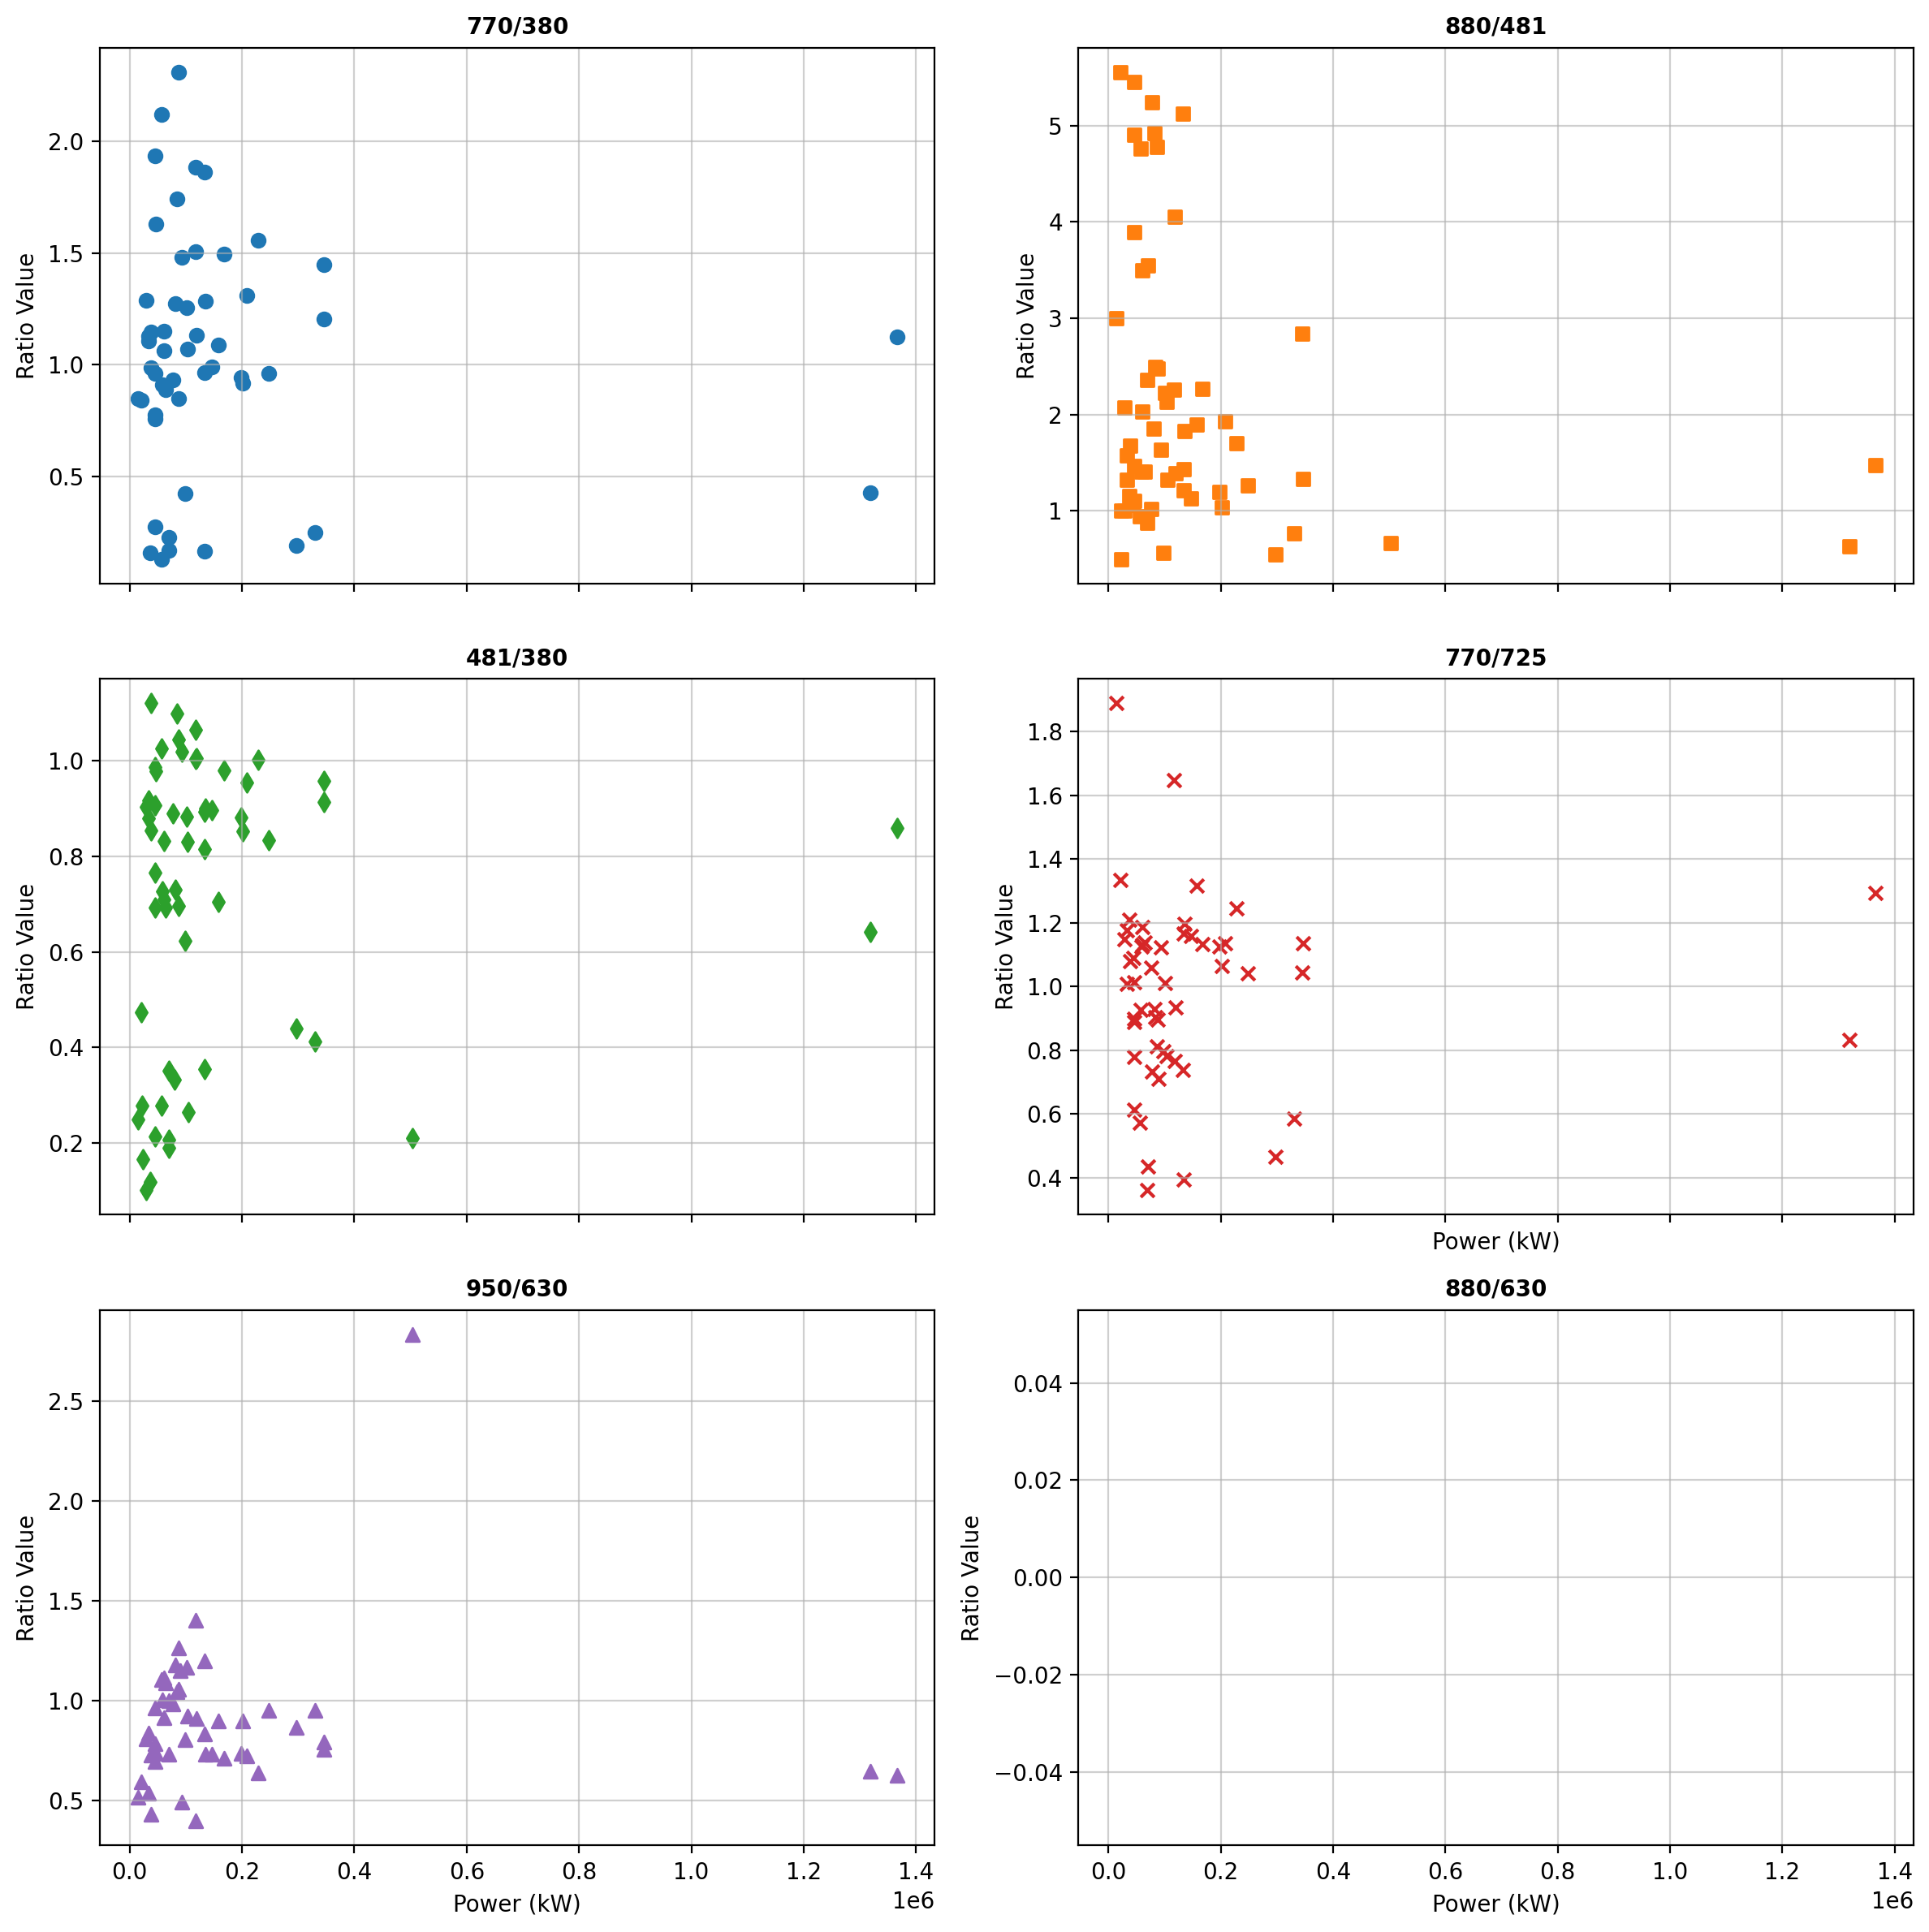

In [135]:


# 2. Define the ratios, markers, and labels for the loop
ratios = ['rat1', 'rat2', 'rat3', 'rat4', 'rat5', 'rat6']
labels = ['770/380', '880/481', '481/380', '770/725', '950/630', '880/630']
markers = ['o', 's', 'd', 'x', '^', 'v']
colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd', '#8c564b']

# 3. Create the subplot array (3 rows, 2 columns)
fig, axes = plt.subplots(3, 2, figsize=(12, 12), dpi=200, sharex=True)
axes = axes.flatten()  # Flatten to 1D array for easy iteration

for i in range(len(ratios)):
    ax = axes[i]
    ratio_col = ratios[i]
    
    # Plot the data
    ax.scatter(summary_df['Voltage_kV']*summary_df['Current_A']*summary_df['Pressure_mTorr'], summary_df[ratio_col], 
            marker=markers[i], color=colors[i], label=labels[i])
    
    # Formatting each subplot
    ax.set_title(labels[i], fontsize=10, fontweight='bold')
    ax.set_ylabel('Ratio Value')
    ax.grid(True, alpha=0.6)
    
    # Only add X-label to the bottom-most plots
    if i >= 3:
        ax.set_xlabel('Power (kW)')


plt.tight_layout()
plt.show()

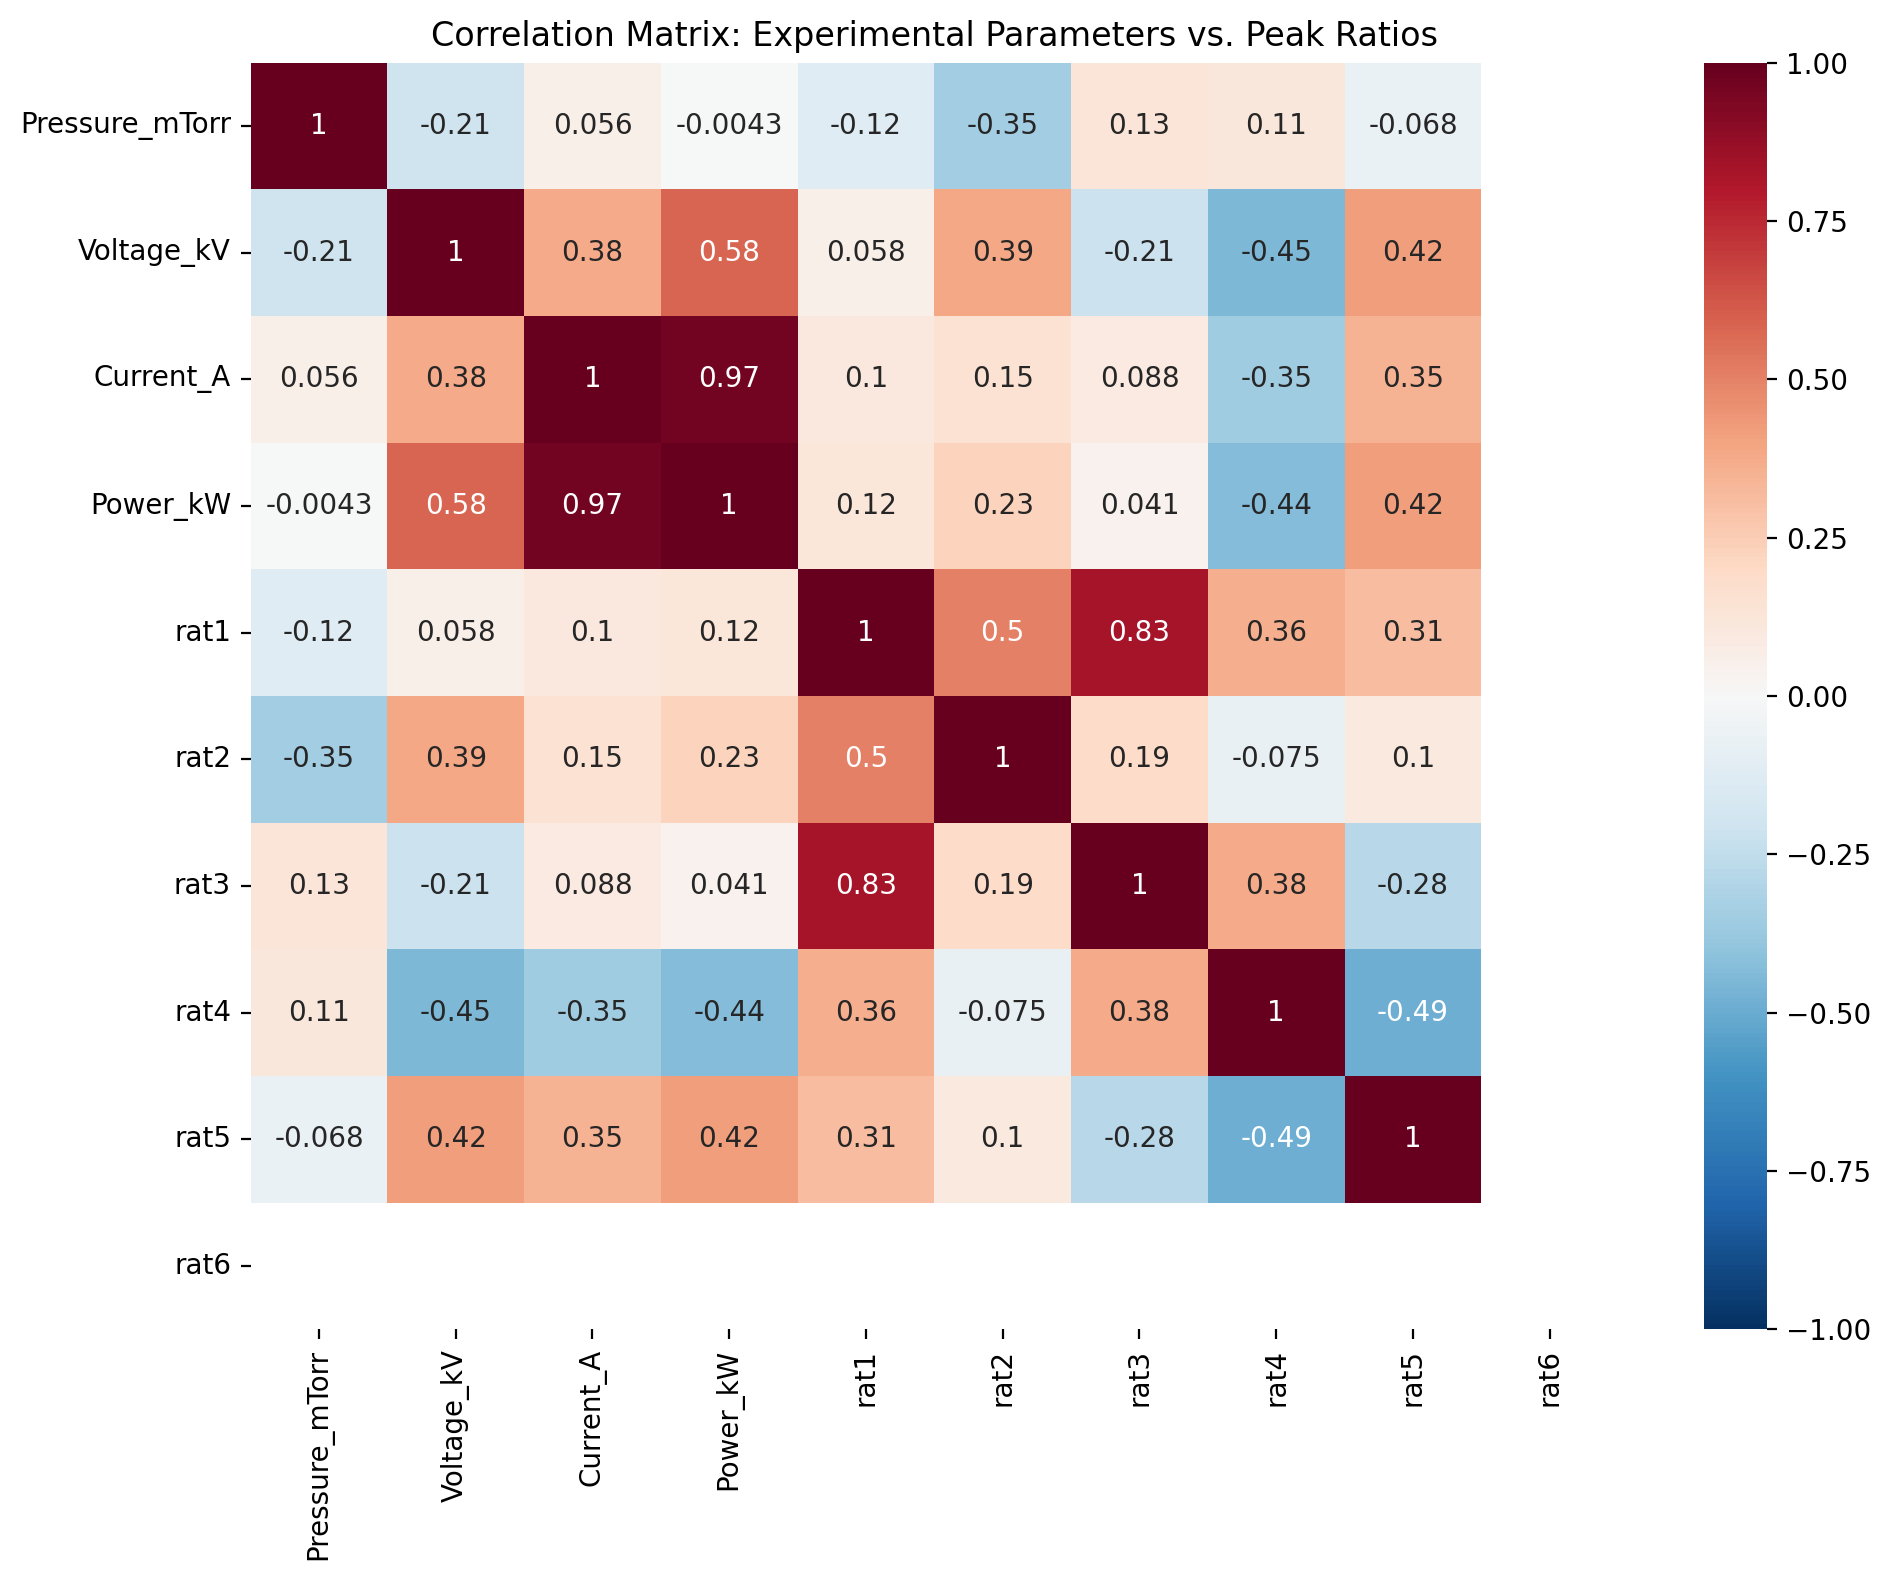

Top correlations for rat1 (770/380):
rat1              1.000000
rat3              0.832777
rat2              0.504007
rat4              0.359474
rat5              0.311124
Power_kW          0.120512
Current_A         0.102876
Voltage_kV        0.057853
Pressure_mTorr   -0.121693
rat6                   NaN
Name: rat1, dtype: float64


In [136]:
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Feature Engineering: Calculate Power
# Since you have kV and Amps, Power will be in kilo-Watts (kW)
summary_df['Power_kW'] = summary_df['Voltage_kV'] * summary_df['Current_A']

# 2. Select the variables for the matrix
# We include the inputs (Pressure, Voltage, Current, Power) and the outputs (ratios)
analysis_cols = [
    'Pressure_mTorr', 'Voltage_kV', 'Current_A', 'Power_kW',
    'rat1', 'rat2', 'rat3', 'rat4', 'rat5','rat6'
]

# 3. Calculate the Pearson Correlation Matrix
corr_matrix = summary_df[analysis_cols].corr()

# 4. Visualize with a Heatmap
plt.figure(figsize=(10, 8), dpi=200)
sns.heatmap(corr_matrix, annot=True, cmap='RdBu_r', center=0, vmin=-1, vmax=1)

plt.title('Correlation Matrix: Experimental Parameters vs. Peak Ratios')
plt.tight_layout()
plt.show()

# 5. Print the strongest correlations for the primary ratio (rat1)
print("Top correlations for rat1 (770/380):")
print(corr_matrix['rat1'].sort_values(ascending=False))